# Day 002 · 量化交易 vs 主观交易 · 中国版
**Quant vs Discretionary** · 阶段 P1 · 量化基础

> 这是一节对照课。我们不站队,但要让你看清量化交易和主观交易这两条路各自的胜负手——决策怎么做、容量能多大、错了往哪儿错、传给下一代靠什么。看完你应该能判断:自己的天性更适合做巴菲特,还是更适合做 Simons,还是先学量化的纪律来规范你的主观判断。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-04  ·  **建议学习时长:** 18 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [7]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [8]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。"""
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(ak.stock_zh_a_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(ak.fund_etf_hist_em(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(ak.stock_zh_index_daily_em(symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(ak.stock_hk_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        # 美股走新浪源(stock_us_daily 直接吃 NVDA / AAPL 裸 symbol;stock_us_hist 要带前缀)
        s = _norm(ak.stock_us_daily(symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(ak.index_us_stock_sina(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(ak.futures_foreign_hist(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        s = _norm(ak.crypto_hist(symbol=sym, period="daily"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 用四个维度把量化与主观的本质差异讲清楚:决策依据、容量、速度、可复制性
- 看懂为什么资金一旦做大,管理人几乎都被迫走向量化或半量化
- 识别散户最常见的'两头不靠'陷阱——既不专注主观也不严守规则
- 评估自己的性格和现状,选一个起步路径(纯主观/主观+量化/纯量化)
- 建立一个心法:用主观提假设,用量化验证;用直觉发现机会,用规则控制规模

## 历史背景:巴菲特 vs Simons:两种伟大的赚钱方式

巴菲特用 65 年时间证明了主观投资的极限:伯克希尔-哈撒韦从 1965 到 2024 年化约 19.8%,核心是少数大重仓 + 极长持有 + 深度认知。他的核心 alpha 是'懂这家公司,懂得比绝大多数人深'。

James Simons 1988 年成立 Renaissance Technologies,旗舰 Medallion 基金 1988-2018 年化约 39%(扣费后 35%),管理规模 100 亿美元,但只对内部员工开放。它的 alpha 是'每天找到 5000 个微小信号,每个胜率 51%,但每天交易 100 次'。这与巴菲特完全相反。

两个人都是史上最伟大的投资者,但他们的方法论几乎对立。问题不是哪种'对',而是哪种适合你。中国市场也有类似的对照:王亚伟代表主观选股的极致,而幻方/九坤/明汯代表量化崛起。最终的胜负不在某一种方法,而在'你能不能认清自己的天性,然后选对的玩法,并坚持 10 年'。

**关键人物:**
- Warren Buffett(主观集中,65 年 19.8% 年化)
- James Simons(量化分散,30 年 35% 年化)
- 王亚伟(中国主观投资代表)
- 梁文锋(幻方量化创始人,中国量化代表)

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 决策依据:经验直觉 vs 规则数据

主观投资的决策依据是'认知':我懂这家公司,懂这个行业,懂这个国家——所以我敢重仓、敢拿住。这种 alpha 来自不对称信息差。

量化投资的决策依据是'统计':我观察到一个稳定的统计规律,我相信它在新数据上还会成立——所以我严格按规则下注。这种 alpha 来自统计规律的存在和坚持执行。

这两种本质不同。一个对'例外'敏感(看见特殊机会),一个对'平均'敏感(寻找重复模式)。一个赚的是深度的钱,一个赚的是广度的钱。

> **举例:** 茅台从 100 块到 2600 块,主观派可能因为深刻理解品牌和现金流而拿了 10 年;量化派可能因为它满足 N 个因子标准在某个月份持有,然后下个月按规则换出去。两种都赚到了钱,逻辑完全不同。


### 2. 信息处理容量:O(1) vs O(N)

人脑处理信息的容量有上限。巴菲特一辈子真正深度跟踪过的公司可能不超过 50 家,真正重仓的不超过 10 家。这是主观投资的天花板:你深度懂多少,你就能管多少 alpha。

量化策略可以同时处理 5000 只 A 股 + 7000 只港股 + 8000 只美股,加上债券、期货、加密。每只标的同时计算 100 个因子,每天扫描一遍。这是量化的本质优势:O(N) 信息处理。

散户的现实:你既没有巴菲特 50 年积累的深度认知,也没有 Renaissance 几十亿美元的数据基础设施。所以散户最优策略往往是'量化思维 + 小范围深度' = 用规则筛出 100 只候选,再用直觉做最终决策。

```
alpha_total = alpha_per_position × N_positions
```


### 3. 决策速度:从分钟级到月级 vs 从微秒级到月级

主观投资的决策速度通常是分钟到日:你看到一个新闻、一份财报,需要一段时间消化、调研、决策。这种速度对长期投资完全够用——你赚的本来就不是 5 分钟的钱。

量化策略覆盖速度的两端:高频量化在微秒级,低频因子在月级。它的优势在于'你能选择速度,而且每一档都能做'。

关键洞察:主观和量化在'月级'是直接竞争的,而且量化在不变的市场结构里有微弱优势(无情绪/无疲劳/可批量)。所以巴菲特能赢主要是因为时间足够长(50+ 年)和 1965 年时市场效率没现在高。今天再做主观月级决策的难度,比 1965 年大得多。

> **举例:** 你想买一只股票,主观流程:看研报→实地调研→朋友交流→拍板,可能 1 周。量化流程:模型扫描→打分→入选→按规则建仓,可能 5 秒。两者都对,但适用的策略不同。


### 4. 可复制性 / 可传承性

主观投资的最大问题是不可复制。巴菲特的能力很难传给查理之外的任何人——伯克希尔接班一直是大问题。彼得·林奇离开富达后,麦哲伦基金再没回到他在的高度。

量化策略写在代码里。一个团队的策略可以让新人 1 个月内学会、2 个月内独立运维。这是机构愿意投资量化的核心原因:可规模化、可传承、可降低人员风险。

散户视角:如果你只想自己做一辈子,不可复制的主观也 OK。但如果你想未来管别人的钱、做基金、传授学生,量化是唯一可扩展的路径。这条课程整体偏量化,就是因为它可以被'写下来教'。

> **举例:** Renaissance Medallion 基金的核心策略代码总行数据传超过 100 万行,几代研究员持续迭代。文艺复兴的护城河是'代码 + 数据 + 流程',而不是某一个明星交易员。


### 5. 错误来源:情绪疲劳 vs 模型数据

主观决策的错误最大来源是行为偏差:过度自信、确认偏差、沉没成本、损失厌恶、羊群效应。Daniel Kahneman 的《思考,快与慢》整本书在讲这个。即使顶级投资人也无法完全克服。

量化的错误来源完全不同:数据脏了(回测被骗)、模型过拟合(样本外失效)、协整破裂(LTCM 死法)、流动性枯竭(2010 闪崩)。这些错误是冷的、机械的,需要工程严谨度防范。

哪种更可怕?长期看主观偏差是慢性病,量化错误是急性病。慢性病每天蚕食你的胜率,急性病某一天突然搞掉你 30% 资金。两者都要警惕,但量化的好处是'错了你能查到代码哪一行错了'。

> **举例:** 2007 年 8 月的'量化危机':多家顶级量化基金在一周内同时巨亏,因为它们用了相似的因子,集体平仓引发踩踏。这不是模型错,而是流动性结构性错。机械错误一旦发生就是同步爆发。


## 实操:用 1000 次模拟看清主观与量化的差异

本节无外部数据,纯模拟/统计运算,国内国外都能跑。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

主观: 中位数 82.9%, 标准差 116.7%
量化: 中位数 46.4%, 标准差 20.7%
主观: 最差 5% 收益 -22.8%
量化: 最差 5% 收益 17.3%


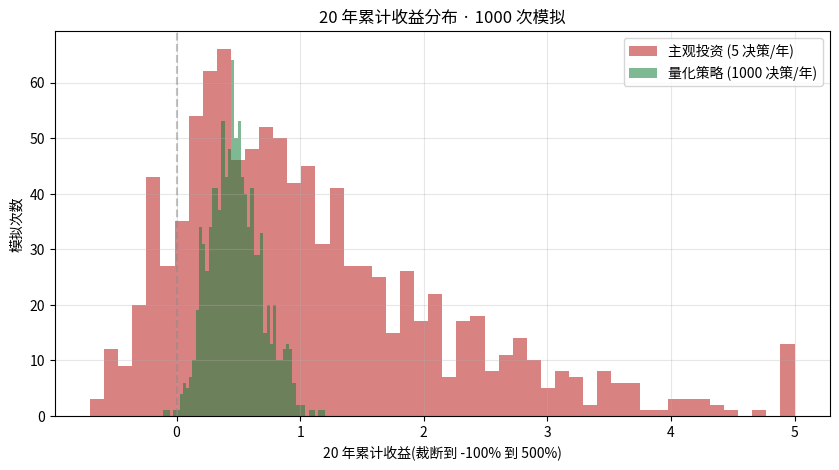

In [9]:
# day_002_quant_vs_discretionary.py — 模拟两种风格的长期收益分布
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N_YEARS = 20
N_TRIALS = 1000

# 主观投资:每年 5 个大决策,熟悉领域 60% 胜率,陌生领域 45% 胜率
def discretionary_year():
    rets = []
    for _ in range(5):
        familiar = np.random.rand() < 0.5
        win_p = 0.60 if familiar else 0.45
        win = np.random.rand() < win_p
        rets.append(0.06 if win else -0.05)  # +6% / -5% 每个决策
    return float(np.sum(rets))  # 5 个决策的年度合计

# 量化策略:每年 1000 次小决策,每次 51% 胜率
def quant_year():
    trades = np.random.choice([0.001, -0.001], size=1000, p=[0.51, 0.49])
    return float(np.sum(trades))  # 千笔小赌的年度合计

# 跑 1000 次 20 年模拟
disc = [(np.prod([1 + discretionary_year() for _ in range(N_YEARS)])) - 1 for _ in range(N_TRIALS)]
quant = [(np.prod([1 + quant_year() for _ in range(N_YEARS)])) - 1 for _ in range(N_TRIALS)]

print(f'主观: 中位数 {np.median(disc)*100:.1f}%, 标准差 {np.std(disc)*100:.1f}%')
print(f'量化: 中位数 {np.median(quant)*100:.1f}%, 标准差 {np.std(quant)*100:.1f}%')
print(f'主观: 最差 5% 收益 {np.percentile(disc,5)*100:.1f}%')
print(f'量化: 最差 5% 收益 {np.percentile(quant,5)*100:.1f}%')

# 画分布对比
plt.figure(figsize=(10, 5))
plt.hist(np.clip(disc, -1, 5), bins=50, alpha=0.55, label='主观投资 (5 决策/年)', color='#b91c1c')
plt.hist(np.clip(quant, -1, 5), bins=50, alpha=0.55, label='量化策略 (1000 决策/年)', color='#15803d')
plt.axvline(0, color='#888', linestyle='--', alpha=0.5)
plt.legend(loc='upper right'); plt.title('20 年累计收益分布 · 1000 次模拟')
plt.xlabel('20 年累计收益(裁断到 -100% 到 500%)'); plt.ylabel('模拟次数')
plt.grid(alpha=0.3)
plt.savefig('day002_compare.png', dpi=120, bbox_inches='tight')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 | 600519 茅台 vs 沪深300 量化指增 | 主观重仓茅台 10 年:大概 12 倍。同期量化指增产品中位数:大概 4 倍。看似主观赢——但 1000 个买茅台的散户里只有 5% 拿满 10 年,其余被波动甩下车。 |
| 美股 | Berkshire (BRK) vs Renaissance Medallion | BRK 65 年年化 19.8%(全部公开)。Medallion 30 年年化 39%(全部内部)。两者风险特征完全不同:BRK 单年最大回撤 -49.7%(2008),Medallion 据称单年从未超过 -5%。 |
| 中国 | 王亚伟 vs 幻方 | 王亚伟 2005-2012 年管理华夏大盘精选,7 年累计 1100%。幻方 2015-2023 八年从 0 到管 1000 亿。两条路代表了中国财富管理两个时代。 |
| 加密 | BTC 拿住派 vs Funding Rate 套利 | 2017 入场拿住 BTC 到 2024 年化约 50%(主观)。同期跨所 + funding 套利组合年化 12-18%(量化)。BTC 拿住派最大回撤 -85%,套利策略最大回撤 -8%。同样'赚到了',但能不能拿住的难度完全不同。 |


## 常见坑

### ⚠ 01. 把量化神话化

以为量化 = 稳赚。实际上量化和主观一样会大幅回撤,只是回撤的来源不同。Renaissance 也亏过钱,LTCM 直接 21 天爆掉。任何承诺稳赚的都是骗子。

### ⚠ 02. 把主观浪漫化

看完巴菲特传记觉得自己也能复制。99% 的主观投资者跑不赢指数。主观投资的难度在于'坚持'与'认知',这两个对绝大多数人都是不可能任务。

### ⚠ 03. 二选一陷阱

认为必须纯量化或纯主观。事实上多数顶级投资人是混合派:用主观直觉发现机会、用量化规则控制规模和风险。最聪明的散户也应该这么做。

### ⚠ 04. 用错地方

拿主观风格做高频(注定亏),拿量化方式做巨额并购套利(数据样本太小)。两种风格各有适用区,选错了就是把锤子用来拧螺丝。

### ⚠ 05. 散户两头不靠

既没有主观投资人 10 年的深度认知,也没有量化机构的工程基础设施。结果是用情绪做决策(主观失败)、用浅薄规则做交易(量化失败)。这是大多数散户实际状态。

## 实战 SOP · 心法:量化 + 主观的混合 SOP

1. 用主观提假设:遇到一个想法,先在脑子里想'为什么会赚钱',形成清晰的经济直觉
2. 用量化验证假设:把直觉写成规则,跑历史回测,看是否在数据里成立
3. 用量化做规模:验证通过后,机械执行,不让情绪干扰仓位
4. 用主观做边界:超出回测样本(极端行情/政策冲击)时,人工介入而不是盲信模型
5. 短期相信规则:1-3 个月内不质疑模型,即使在亏损
6. 长期质疑规则:1-3 年定期 review,过期了的规则及时下架
7. 永远只做你能解释的策略:跑出夏普 5.0 但你说不清楚原理的——大概率是过拟合,远离它

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 主观和量化是两种本质不同的赚钱方式,各自的 alpha 来源完全不同。
3. 决策依据:主观靠认知,量化靠统计。容量:主观 O(1),量化 O(N)。
4. 速度:量化覆盖微秒到月,主观集中在分钟到周。可复制性:量化能传,主观难传。
5. 错误来源:主观是慢性的认知偏差,量化是急性的模型/数据失效。
6. 大资金最终都走向量化或半量化,因为可规模化和可传承是机构刚需。
7. 散户最常见的死法是'两头不靠':没有真正的主观深度,也没有真正的量化纪律。
8. 心法是混合:用主观提假设/做边界,用量化做验证/做规模/做风控。
9. 评估自己的天性比选方法更重要:你是 Buffett 型还是 Simons 型,这决定 365 天的学习重点。

## 自测题

**Q1.** 你最近一次的投资决策,是基于'我懂这家公司'还是'数据显示有规律'?
**Q2.** 如果你管理 10 万,主观可行;如果管理 1 亿,你还能用主观方式吗?
**Q3.** 你能列出 3 个你比 90% 投资者更深的领域吗?如果不能,起步选量化更合理。

把答案写下来,3 天后再回看。

## 下一节预告

**Day 003 · 量化的三大流派** (Three Schools)

Day 3:量化的三大流派 — 不是所有量化都一样。统计套利、高频做市、因子投资,三种完全不同的子文化,选哪条路决定你接下来 3 个月的学习重点。

## 推荐阅读

- 《投资中最简单的事》邱国鹭 — 主观派代表读物,逻辑朴素
- 《股市真规则》Pat Dorsey — Morningstar 主观选股框架
- 《Inside the Black Box》Rishi Narang — 量化基金内部视角
- 《思考,快与慢》Daniel Kahneman — 看清主观决策的认知偏差
- 巴菲特致股东信 1957-2024(免费,annualreports.berkshirehathaway.com) — 一辈子的主观投资笔记